# Clustering

**Solución:** https://colab.research.google.com/drive/1ccFKhL9MGeIsgKIP8oNySU1aKYiJ_11j?usp=sharing

**Challenge:** https://colab.research.google.com/drive/1outX-txjrv_AnMeY_uda9DIjRiSRMPol?usp=sharing

"If intelligence was a cake, unsupervised learning would be the cake, supervised learning would be the icing on the cake, and reinforcement learning would be the cherry on the cake" - Yann LeCun

Análisis de Agrupamientos: Proceso de particionamiento de un conjunto de datos (u observaciones) en subconjuntos. Cada subconjunto es un grupo o cluster.

* Los datos en un mismo cluster deben ser similares entre sí.
* Los datos de diferentes clusters deben ser diferentes entre sí.

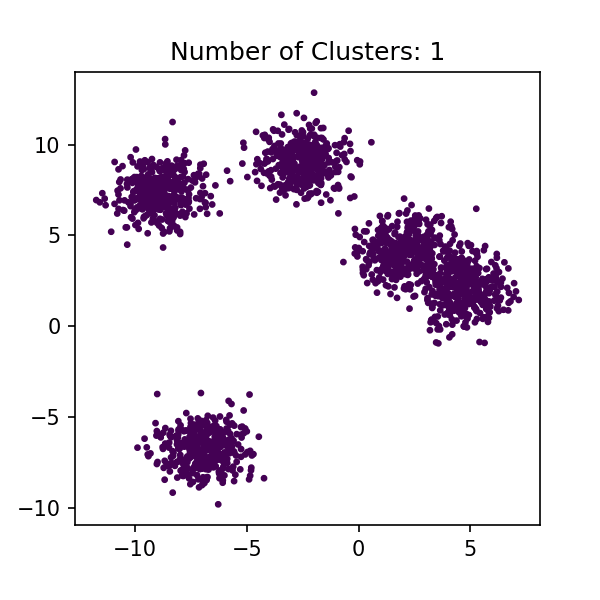

## K-Means

* Método que permite crear __clusters__ a partir de __datos numéricos__. El input del sistema son las mediciones numéricas de interés y los outputs son:
    * los centroides de los __clusters__ resultantes
    * la asignación de cada dato a un __cluster__ determinado.

* El __centroide__ es el punto que se encuentra en el centro de un __cluster__, (es la media de las coordenadas de todos los puntos de ese __cluster__).

* El número de centroides `k` es definido según convenga, para definir la distancia entre puntos y entre centroides se suele utilizar la distancia euclídea.

* La __inercia__ del modelo es la métrica de rendimiento usada para saber donde colocar mejor los centroides, la inercia del modelo es la
distancia media cuadrática entre cada observación y su centroide más cercano.

La Inercia o __Within sum of squares__ se obtiene:

$WSS = \sum_{i = 1}^{K}\sum_{j = 1}^{n_i}{\mid x_{ij} - c_i\mid}^2$

donde:

- $K$, es el número de centroides
- $n_i$, es el número de elementos que pertenecen al centroide $i$
- $c_i$, centroide del cluster $i$
- $x_{ij}$, elemento $j$ del cluster $i$

### Implementación en Scikit-learn

#### Inspección visual (ternary plot)

### Seleccionamos el numero de clusters

#### `n_clusters`

De forma arbitraria seleccionamos el valor del hiperparametro `n_clusters=3`

#### `inertia_`

Obtenemos la inercia del modelo

También puede ser obtenido en su formato negativo bajo el protocolo de sklearn dónde "entre mas grande mejor"

#### `cluster_centers_`

Obtenemos los centroides

### Agregamos nuevas observaciones a nuestros clusters

a __K-MEANS__ todo lo que importa al asignar una observación
a un cluster es la distancia al centroide.

### Número optimo de clusters

#### Regla del codo

En general, no es fácil establecer el `k` optimo a priori y elegir el modelo con la menor inercia no es una buena idea ya que está regularmente disminuye a medida que aumentamos k, entonces La inercia no es una buena métrica de rendimiento.

A medida que aumentamos k, la inercia cae muy rápid. Esta curva tiene aproximadamente la forma de un brazo, y hay un "codo" en k = 3.

__SI NO TUVIERAMOS MAS CONOCIMIENTO DE LOS DATOS k = 3 SERíA UNA BUENA OPCIÓN__

* Cualquier valor antes del codo sería dramático
* Cualquier valor despues del codo no ayudaría mucho, ya que podríamos simplemente estar dividiendo grupos perfectamente buenos por la mitad sin una buena razón.

Entonces, __si no hay información que ayude a tomar una mejor decisión, el valor del codo es la mejor opción__.

__NOTA__: En general este proceso no es sencillo y hay que tener en cuenta que K-Means es muy sensible a diferencias en las varianzas de las variables y a variables con escalas muy distintas.

#### Silhouette

* Un enfoque más preciso (pero también computacionalmente más costoso) es utilizar el __Silhouette score__.

* El __Silhouette score__ es el silhouette medio sobre todas las instancias.

* El Silhouette de una instancia se define cómo $\frac{b-a}{max(a, b)}$ dónde:
    * $a$ es la distancia media a otras instancias en el mismo cluster (la distancia intra cluster media)
    * $b$ es la media de la distancia al cluster mas cercano (la distancia media a las instancias del siguiente cluster, definida como la que minimiza a $b$, excluyendo la distancia del propio cluster)

* El coeficiente Silouette está entre -1 y 1 esto se interpreta:
    * Entre mas cerca está de 1, significa que la instancia está bien dentro de su cluster y lejos de otros clusters
    * Entre mas cerca está de 0, significa que está muy cerca de una frontera entre clusters
    * Entre mas cerca está de -1 significa que la instancia ha sido asignada a un cluster donde no corresponde

##### Silhouette scores

Está visualización es mas informativa que la gráfica del codo, en esta visualización observamos que `k=2` es un excelente `k`, pero `k=3` también es una excelente opción, estas opciones son mucho mejores que el resto, esta gráfica puede llegar a ser mas informativa que solo comparar inercias.

##### Silhouette diagrama

Una visualización aun mas informativa se obtiene cuando gráficamos el silhouette de cada instancia, agrupada por los clusters que los contiene y ordenada por sus valores.

Cada diagrama tiene forma de cuchillo por cluster:
* La altura del cuchillo significa la cantidad de instancias que contiene el cluster
* El ancho representa los coeficientes silhouette ordenados en el cluster (entre mas ancho mejor)
* La linea punteada representa el coeficiente silhouette medio

#### Recomendaciones para K-means

* Normalizar las variables antes de hacer K-means, restar a cada variable su media y dividirla por la desviación típica